#### HUC12 maps of KGE

Creates HUC12 maps of KGE for public supply and irrigation water use predictions. 

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable 
import tempfile
import imageio.v2 as imageio
import numpy as np

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures/HUC12_KGE_maps")
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
##### ---------- MANUAL SET UP ----------

scenarios = [
    {
        'scenario': 'calibration',
        'run_dates': {
            'GBSJ': '2026-07-16',
            'LCRR': '2026-07-16',
            'MILK': '2026-07-16',
        }
    }
]

In [3]:
##### ---------- IMPORT GEO BOUNDARIES ----------

GBSJ_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/GBSJ_HUC12.shp")
LCRR_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/LCRR_HUC12.shp")
MILK_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/MILK_HUC12.shp")

# get column in right format for merge 
GBSJ_huc12 = GBSJ_huc12.rename(columns={"huc12": "HUC12"})
LCRR_huc12 = LCRR_huc12.rename(columns={"huc12": "HUC12"})
MILK_huc12 = MILK_huc12.rename(columns={"huc12": "HUC12"})

GBSJ_huc12['HUC12'] = GBSJ_huc12['HUC12'].astype(int)
LCRR_huc12['HUC12'] = LCRR_huc12['HUC12'].astype(int)
MILK_huc12['HUC12'] = MILK_huc12['HUC12'].astype(int)

# prep CRS for maps
target_crs = GBSJ_huc12.crs

LCRR_huc12 = LCRR_huc12.to_crs(target_crs)
MILK_huc12 = MILK_huc12.to_crs(target_crs)

In [4]:
##### ---------- PREP DATA ----------

def prep_data(watershed, scenarios):

    ### ----- PREP USGS VALIDATION DATA -----
    USGS_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/USGS_validation.csv")
    USGS_data.loc[USGS_data["Watershed"] == "GBSJ", "in_us"] = 1
    USGS_data = USGS_data[USGS_data["in_us"] != 0]

    data_for_fig = USGS_data

    ### ----- LOOP OVER SCENARIOS, MERGE EACH ONE IN -----
    all_regions = pd.read_csv('/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/US_region_list.csv')
    all_regions = all_regions.rename(columns={'huc12': 'HUC12'})

    for s in scenarios:
        scenario = s['scenario']
        run_date = s['run_dates'][watershed]

        # load data
        model_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/{scenario}-{run_date}.csv")

        # filter out non-US HUCs
        model_data = model_data.merge(all_regions, on='HUC12', how='left')
        model_data.loc[model_data["Watershed"] == "GBSJ", "in_us"] = 1
        model_data = model_data[model_data["in_us"] != 0]

        # merge this scenario's columns into the growing data_for_fig
        data_for_fig = data_for_fig.merge(model_data, on=['Year', 'HUC12', 'Watershed', 'in_us'], how='right')

    return data_for_fig

### ----- RUN FOR EACH WATERSHED -----

watersheds = ['GBSJ', 'LCRR', 'MILK']
data_for_fig = {w: prep_data(w, scenarios) for w in watersheds}

In [5]:
##### ---------- COMPUTE KGE ----------

# function to calculate KGE
def kge(obs, pred):
    obs = np.asarray(obs, dtype=float)
    pred = np.asarray(pred, dtype=float)
    mask = ~np.isnan(obs) & ~np.isnan(pred)
    obs, pred = obs[mask], pred[mask]
    if len(obs) < 2:
        return np.nan
    if obs.std() == 0 or obs.mean() == 0:
        return np.nan
    r = np.corrcoef(obs, pred)[0, 1]
    alpha = pred.std() / obs.std()
    beta = pred.mean() / obs.mean()
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

# function to split calibration and validation periods
def assign_period(year):
    if 2000 <= year <= 2015:
        return 'calibration'
    elif 2016 <= year <= 2020:
        return 'validation'
    else:
        return None

# function to compute KGEs
def compute_huc12_kge(df, variables=('public_supply_mil_gal', 'irrigation_mil_gal')):
    df = df.copy()
    df['period'] = df['Year'].apply(assign_period)
    df = df[df['period'].notna()]

    records = []
    for huc12, g in df.groupby('HUC12'):
        row = {'HUC12': huc12}
        for period in ['calibration', 'validation']:
            gp = g[g['period'] == period]
            for var in variables:
                obs_col = f'{var}_validation'
                pred_col = f'{var}_calibration'
                if obs_col in gp.columns and pred_col in gp.columns:
                    row[f'{var}_kge_{period}'] = kge(gp[obs_col], gp[pred_col])
                else:
                    row[f'{var}_kge_{period}'] = np.nan
        records.append(row)

    return pd.DataFrame(records)

### ----- RUN FOR EACH WATERSHED -----
watersheds = ['GBSJ', 'LCRR', 'MILK']
kge_by_huc12 = {w: compute_huc12_kge(data_for_fig[w]) for w in watersheds}

/users/c/m/cmanitiu/.conda/envs/cmanitiu/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/users/c/m/cmanitiu/.conda/envs/cmanitiu/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/users/c/m/cmanitiu/.conda/envs/cmanitiu/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/users/c/m/cmanitiu/.conda/envs/cmanitiu/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/users/c/m/cmanitiu/.conda/envs/cmanitiu/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/users/c/m/cmanitiu/.conda/envs/cmanitiu/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: Runtime

/tmp/ipykernel_1262845/3419864174.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])


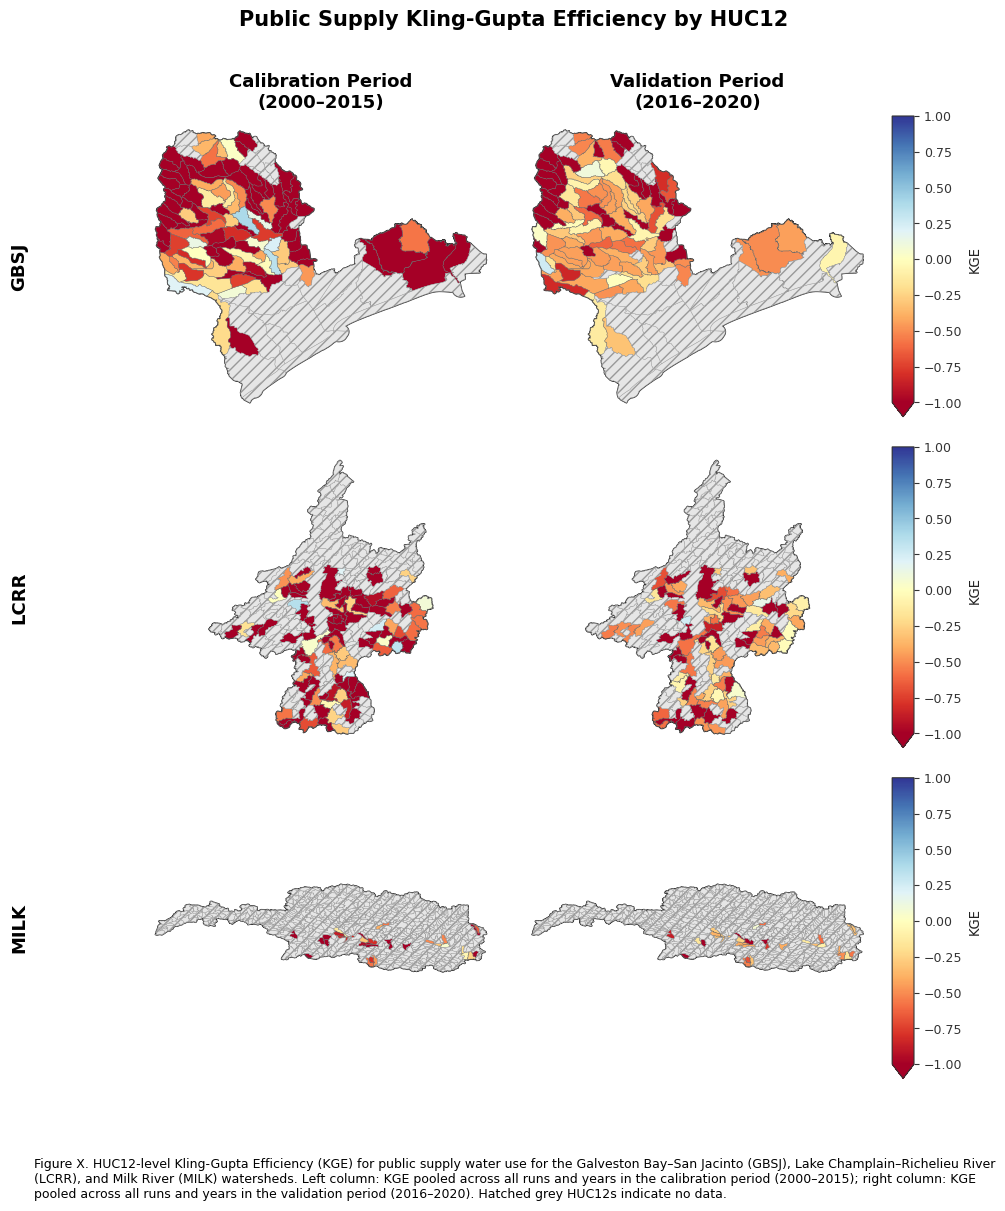

/tmp/ipykernel_1262845/3419864174.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])


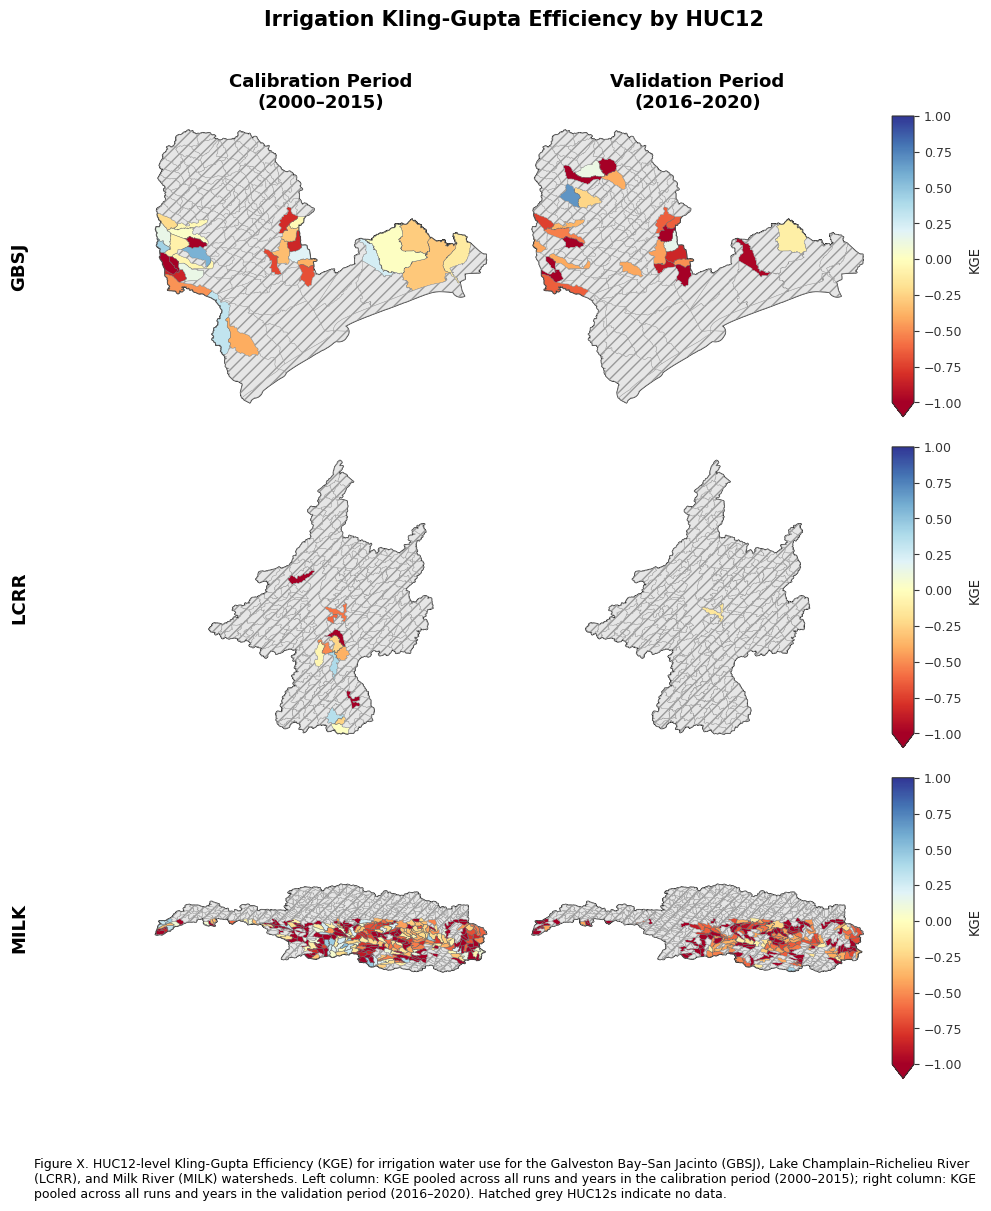

In [6]:
##### ---------- HUC12 CHOROPLETH MAPS: KGE, CALIBRATION vs. VALIDATION PERIOD ----------

geo_lookup = {
    'GBSJ': GBSJ_huc12,
    'LCRR': LCRR_huc12,
    'MILK': MILK_huc12,
}

water_use_types = [
    ('public_supply_mil_gal', 'Public Supply'),
    ('irrigation_mil_gal', 'Irrigation'),
]

PERIOD_PANELS = [
    ('calibration', 'Calibration Period\n(2000–2015)'),
    ('validation', 'Validation Period\n(2016–2020)'),
]

# fixed legend range for KGE
# KGE technically has no lower bound, but -0.41 is the standard "worse than
# using the observed mean" benchmark — clip below that so a few bad HUC12s
# don't wash out the color scale. Adjust VMIN if you'd rather see raw extent.
KGE_VMIN = -1
KGE_VMAX = 1
KGE_CMAP = 'RdYlBu'  # red = poor fit, blue = good fit

##### ---------- STYLE ----------

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MISSING_KWDS = dict(color='#e6e6e6', edgecolor='#999999', linewidth=0.3, hatch='///', label='No data')


##### ---------- BUILD ONE FIGURE PER WATER-USE TYPE ----------

for use_key, use_label in water_use_types:

    fig = plt.figure(figsize=(10, 12.5))
    gs = gridspec.GridSpec(
        nrows=3, ncols=3, width_ratios=[1, 1, 0.06],
        wspace=0.05, hspace=0.10, figure=fig
    )

    cmap = plt.get_cmap(KGE_CMAP).copy()
    norm = Normalize(vmin=KGE_VMIN, vmax=KGE_VMAX)

    row_first_axes = []

    for row, watershed in enumerate(watersheds):

        ax_cal = fig.add_subplot(gs[row, 0])
        ax_val = fig.add_subplot(gs[row, 1])
        cax = fig.add_subplot(gs[row, 2])
        row_first_axes.append(ax_cal)

        geo = geo_lookup[watershed]
        huc_kge = kge_by_huc12[watershed]  # has both period columns already

        axes = [ax_cal, ax_val]

        for ax, (period_suffix, period_title) in zip(axes, PERIOD_PANELS):
            kge_col = f'{use_key}_kge_{period_suffix}'
            merged = geo.merge(huc_kge[['HUC12', kge_col]], on='HUC12', how='left')

            if kge_col in merged.columns:
                # clip values into the fixed legend range for coloring
                # (raw KGE value is preserved in kge_col for reference/export)
                plot_col = f'__{use_key}_plot'
                merged[plot_col] = merged[kge_col].clip(lower=KGE_VMIN, upper=KGE_VMAX)

                merged.plot(
                    column=plot_col, cmap=cmap, norm=norm,
                    linewidth=0.3, edgecolor='#666666',
                    missing_kwds=MISSING_KWDS,
                    ax=ax, zorder=2
                )
            else:
                merged.plot(**MISSING_KWDS, ax=ax, zorder=2)

            # watershed outline on top
            geo.dissolve().boundary.plot(ax=ax, color='#333333', linewidth=1.2, zorder=0)

            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_aspect('equal')

            if row == 0:
                ax.set_title(period_title, fontsize=13, fontweight='bold', pad=6)

        # ----- shared colorbar for this row, with overflow arrow for KGE < -1 -----
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax, extend='min')
        cb.set_label('KGE', fontsize=9.5)
        cb.ax.tick_params(labelsize=9)

    ##### ---------- SUPTITLE ----------
    fig.suptitle(
        f'{use_label} Kling-Gupta Efficiency by HUC12',
        fontsize=15, fontweight='bold', y=0.965
    )

    ##### ---------- CAPTION ----------
    caption_text = (
        f"Figure X. HUC12-level Kling-Gupta Efficiency (KGE) for {use_label.lower()} water use for the Galveston Bay–San Jacinto (GBSJ), Lake Champlain–Richelieu River\n"
        f"(LCRR), and Milk River (MILK) watersheds. Left column: KGE pooled across all runs and years in the calibration period (2000–2015); right column: KGE\n"
        f"pooled across all runs and years in the validation period (2016–2020). Hatched grey HUC12s indicate no data."
    )
    fig.text(0.02, 0.012, caption_text, ha='left', va='bottom', fontsize=9, wrap=True)

    fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])

    ##### ---------- ALIGN WATERSHED ROW LABELS ----------
    for watershed, ax in zip(watersheds, row_first_axes):
        pos = ax.get_position()
        y_center = (pos.y0 + pos.y1) / 2
        fig.text(
            0.005, y_center, watershed,
            rotation=90, va='center', ha='center',
            fontsize=13, fontweight='bold'
        )

    save_path = out_dir / f"{use_key}_kge.png"
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
